# Workshop 1.2 Numerical Modelling

*[CEGM1000 MUDE](http://mude.citg.tudelft.nl/)*

*Written by: Ronald Brinkgreve, Anna Störiko*

*Due: Wednesday, September 9, 2026.*

# Part 2: Numerical solution of a linear ODE

## Reservoir storage and discharge

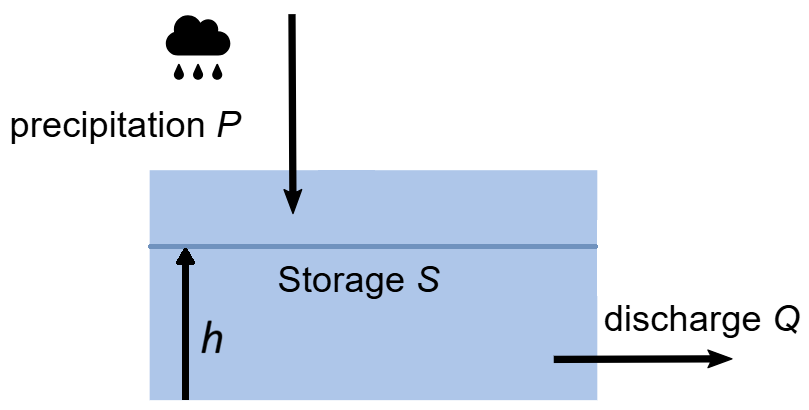

As a measure to cope with climate change, the municipality of a metropolis considers the construction of a big underground reservoir collecting rainwater for a part of the city as a buffer in periods of heavy rain, to prevent urban flooding. Above the minimum water level $h_{min}$, which acts as a reserve for the fire brigade to intake water for fire extinction, water can outflow the reservoir into the sewage system with reduced capacity. As a simplification, this outflow discharge is assumed proportional to the water level above the minimum level. Hence, the water level in the reservoir depends on both precipitation and discharge, while the latter is zero below the minimum level. If it rains heavily, the reservoir is filled up ($h$ will increase) and in case of little or no rain, the reservoir will empty ($h$ will decrease) down to the minimum level. The simplified system can be described by the following ordinary differential equation (ODE):

$$A_R\frac{dh}{dt} = A P(t)/1000 - K \left(h - h_{min} \right)$$

where:</p>
    $h$ is the water level in the reservoir</p>
    $t$ is the time</p>
    $A_R$ is the storage area of the reservoir</p>
    $A$ is the total area above ground from which precipitation is collected</p>
    $P(t)$ is the precipitation (measured on frequent regular time intervals in $mm/hour$)</p>
    $K$ is a term that defines the proportionality of the discharge with respect to the water level in $m^2/hour$

All areas are defined in $m^2$, while $h$ is defined in $m$ and $t$ in $hour$.

The maximum reservoir depth is 20 m. The idea is to design the size (base area) of the reservoir ($A_R$) based on a design precipitation scheme of 200 mm in 48 hours, using an initial estimate of 7000 $m^2$ (the size of a football field).

>
>**Task 2.1**
>
>Run the cells below to visualise the precipitation in the considered 48 hour time frame:
>
></p>
></div>

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
import numpy as np

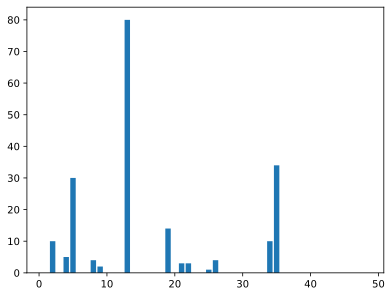

Total discharge in 48 hours: 200 mm


In [2]:
AR = 7000       # Reservoir's base area
A  = 1000000    # Precipitation collection area (1 km^2)
K  = 200        # Discharge factor
h_min = 2.0     # Minimum reservoir level

hours = 48
t_data = np.arange(1, hours + 1)

P_data = np.array([0, 10, 0, 5, 30, 0, 0, 4, 2, 0, 0, 0, 80, 0, 0, 0, 0, 0, 14, 0, 3, 3, 0,
             0, 1, 4, 0, 0, 0, 0, 0, 0, 0, 10, 34, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

plt.bar(t_data, P_data)
plt.show()

print(f'Total discharge in 48 hours: {np.sum(P_data)} mm')

(Alternatively, read an input file with precipitation data)

>
>**Task 2.2**
>
>Formulate the Forward Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>
></p>
></div>

In [11]:
h = np.zeros(len(t_data))

for i in range(0, len(t_data)-1, 1):        #iterating across time array
    dhdt = (A/AR)*(P_data[i]/1000) - (K/AR)*(h[i] - h_min)    #define dhdt with initially empy resevoir
    dt = t_data[i+1] - t_data[i]            #calculate time step
    h[i+1] = h[i]+dt*dhdt                    #assess h at next step



    #Is this a coding or theory question?, 
    # (are we meant to just write the above questions but not as usable code)


>
>**Task 2.3**
>
>Complete and run the code cells below to calculate $h_{i+1}$ for all time steps until the end of the time interval, considering $h_0 = h_{min}$.
>
></p>
></div>

In [10]:
h = np.zeros(len(t_data))
h[0] = h_min
for i in range(0, len(t_data)-1, 1):        #iterating across time array
    dhdt = (A/AR)*(P_data[i]/1000) - (K/AR)*(h[i] - h_min)    #define dhdt with initially empy resevoir
    dt = t_data[i+1] - t_data[i]            #calculate time step
    h[i+1] = h[i]+dt*dhdt                    #assess h at next step


### Data initialisation

In [27]:
# Define the time step and create solution time points
dt = 0.1        # 0.1 hours = 6 minutes
num = int(hours / dt)
print(f"Number of time steps: {num}")
t = np.linspace(0, hours, num+1)

# Interpolate precipitation data to solution time points
indices = np.searchsorted(t_data, t, side='left')
P = P_data[indices]                                #create array of rate of rain at every time step(P_data across hour)

assert len(P) == len(t)
#print(num)

Number of time steps: 480


### Forward Euler scheme

In [28]:
h = np.zeros_like(t) # create an array to store the reservoir level at each time step

h[0] = h_min

for i in range(num):
    dhdt = (A/AR)*(P[i]/1000) - (K/AR)*(h[i] - h_min)    #define dhdt 
    dt = t[i+1] - t[i]            #calculate time step
    h[i+1] = h[i]+dt*dhdt    

>
>**Task 2.4**
>
>Run the code cell below to plot the results
>
></p>
></div>

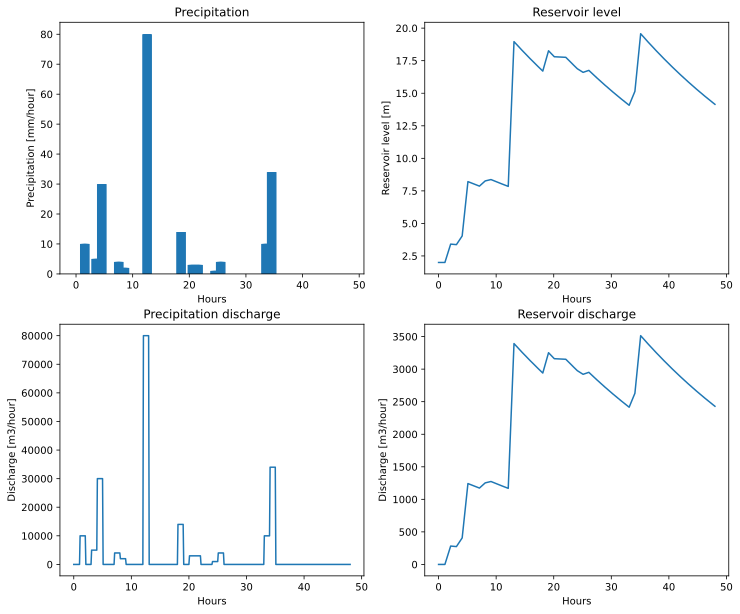

In [29]:
def plot_figs():
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    ax[0,0].bar(t, P, label='Precipitation')
    ax[0,0].set_xlabel('Hours')
    ax[0,0].set_ylabel('Precipitation [mm/hour]')
    ax[0,0].set_title('Precipitation')

    ax[0,1].plot(t, h, label='Reservoir level')
    ax[0,1].set_xlabel('Hours')
    ax[0,1].set_ylabel('Reservoir level [m]')
    ax[0,1].set_title('Reservoir level')

    ax[1,0].plot(t, P*A/1000, label='Precipitation discharge')
    ax[1,0].set_xlabel('Hours')
    ax[1,0].set_ylabel('Discharge [m3/hour]')
    ax[1,0].set_title('Precipitation discharge')

    ax[1,1].plot(t, K*(h-h_min), label='Reservoir discharge')
    ax[1,1].set_xlabel('Hours')
    ax[1,1].set_ylabel('Discharge [m3/hour]')
    ax[1,1].set_title('Reservoir discharge')

plot_figs()

>
>**Task 2.5**
>
>Write a function (print_max()) to print the maximum values of:
>* The reservoir level
>* The maximum discharge flowing into the reservoir according to the design precipitation scheme
>* The maximum discharge from the reservoir
>
></p>
></div>

In [42]:
def print_max(data):
    max = 0
    for values in data:
        if values > max:
            max = values

    max2 = np.max(data)
    if max == max2:
        #print("success of methods!!")
        return max

    ### YOUR CODE HERE ###

#print("Max in P:", print_max(P), "mm/hr")
print("Max in h:", print_max(h), "m")
print("Max in Resevoir Discharge:",print_max(P*A/1000), "m^3/hr")
print("Max in Area Discharge:",print_max(K*(h-h_min)), "m^3/hr")

Max in h: 19.571340219960252 m
Max in Resevoir Discharge: 80000.0 m^3/hr
Max in Area Discharge: 3514.2680439920505 m^3/hr


>
>**Task 2.6**
>
>Verify (analytically) the stability of the Forward Euler solution. Give the expression for the condition of stability. 
>
></p>
></div>

$$ \Delta t  <  2 \frac{A_R}{K} $$




>
>**Task 2.7**
>
>Formulate the Backward (Implicit) Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>
>Hints: 
>* Refer to next week's lecture or Section 1.2 in the book for an application of the Backward Euler scheme:
>* It may be useful to introduce $h^*$ as an offset to $h$ considering $h_{min}$:
>
>$$h^* = h - h_{min} $$
></p>
></div>

>
>**Task 2.8**
>    
>Complete and run the code cell below to calculate $h_{i+1}$ for all time steps until the end of the time interval using the Backward Euler scheme.
>
></p>
></div>

### Backward Euler scheme

In [59]:
h_star = np.zeros_like(t)

h_plus = np.zeros_like(t)
#h_plus[0] = h_min
 #   dhdt = (A/AR)*(P[i]/1000) - (K/AR)*(h[i] - h_min)
### YOUR CODE HERE ###

for i in range(num):
    h_plus[i+1] = (h_plus[i]+(dt*((A/AR)*(P[i+1]/(1000)))+((K/AR)*h_min)))/(1+((dt*K)/AR))
    ### YOUR CODE HERE ###


Plotting the results

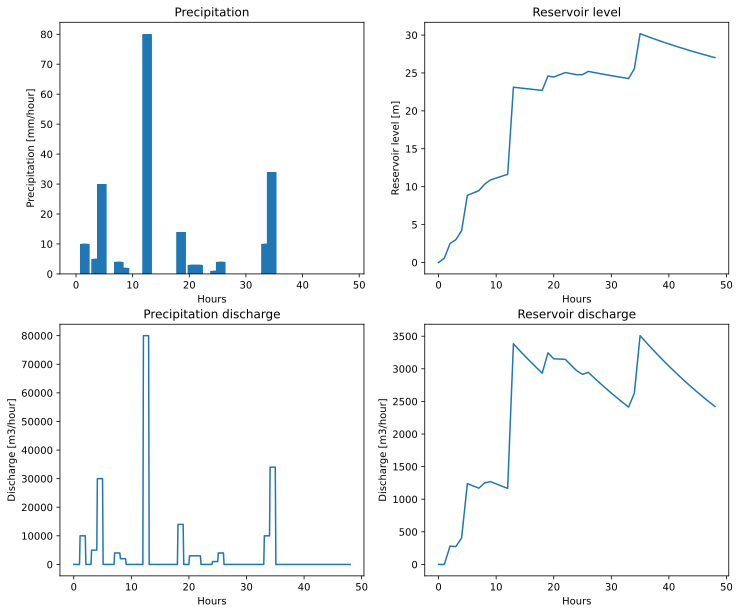

In [ ]:
def plot_figs():
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    ax[0,0].bar(t, P, label='Precipitation')
    ax[0,0].set_xlabel('Hours')
    ax[0,0].set_ylabel('Precipitation [mm/hour]')
    ax[0,0].set_title('Precipitation')

    ax[0,1].plot(t, h_plus, label='Reservoir level')
    ax[0,1].set_xlabel('Hours')
    ax[0,1].set_ylabel('Reservoir level [m]')
    ax[0,1].set_title('Reservoir level')

    ax[1,0].plot(t, P*A/1000, label='Precipitation discharge')
    ax[1,0].set_xlabel('Hours')
    ax[1,0].set_ylabel('Discharge [m3/hour]')
    ax[1,0].set_title('Precipitation discharge')

    ax[1,1].plot(t, K*(h_plus-h_min), label='Reservoir discharge')
    ax[1,1].set_xlabel('Hours')
    ax[1,1].set_ylabel('Discharge [m3/hour]')
    ax[1,1].set_title('Reservoir discharge')

plot_figs()

printing the maximum values

In [ ]:
print("MAximum res level:", print_max(h_plus))
print("Max Precip.", print_max(P*A/1000))
print("Max res. disch.", print_max(K*(h_plus-h_min)))

MAximum res level: 30.1748388100983
Max Precip. 80000.0
Max res. disch. 5634.96776201966


>
>**Task 2.9**
>
>Comment on the suitability of the reservoir in terms of:
>* Its capacity in view of the design precipitation scheme
>* Its capacity in view of the total design precipitation in 48 hours (what if the precipitation distribution over 48 hours is different?)
>* Its function to act as a buffer preventing overflow of the sewage system
>
>What would you advise the municipality?
>
></p>
></div>

> By Ronald Brinkgreve and Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).